In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from keras.utils import to_categorical 
from keras.models import Sequential 
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
import cv2
np.random.seed(42)



In [ ]:
#--------------------------------------------------#
# Loading the dataset
#--------------------------------------------------#

'''train_path = r"/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Train"

data = []
labels = []
classes = 43

for label in range(classes):
    data_path = os.path.join(train_path, str(label))  # train_path should point to /train
    images = os.listdir(data_path)
    
    for img_name in images:
        try:
            img_path = os.path.join(data_path, img_name)  # safe path joining
            img = Image.open(img_path)
            img = img.resize((30, 30))
            img = np.array(img)  # convert to numpy array
            data.append(img)
            labels.append(label)
        except Exception as e:
            print(f'Error loading image {img_name}: {e}')

data = np.array(data)
labels = np.array(labels)
print('Dataset:', data.shape, ',', 'Labels:',labels.shape)
'''









data = []
labels = []

# train_path should point to the base train folder
# Example: "/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Train"
train_path = r"/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Train"
class_folders = sorted(os.listdir(train_path))  # list all class subfolders

for label, folder in enumerate(class_folders):
    data_path = os.path.join(train_path, folder)
    images = os.listdir(data_path)

    for img_name in images:
        try:
            img_path = os.path.join(data_path, img_name)
            img = Image.open(img_path)
            img = img.resize((30, 30))
            img = np.array(img)
            
            # Handle grayscale vs RGB (make all 3 channels)
            if img.ndim == 2:  # grayscale
                img = np.stack((img,) * 3, axis=-1)
            
            data.append(img)
            labels.append(label)
        except Exception as e:
            print(f'Error loading image {img_name}: {e}')

data = np.array(data, dtype=np.float32) / 255.0   # normalize
labels = np.array(labels)

print('Dataset:', data.shape, ',', 'Labels:', labels.shape)
print('Number of classes detected:', len(class_folders))


NotADirectoryError: [Errno 20] Not a directory: '/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Meta.csv'

In [74]:
#--------------------------------------------#
#Splitting training and testing dataset
#--------------------------------------------#
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print('X_train:', X_train.shape, 'X_test:',X_test.shape, 'y_train:', y_train.shape, 'y_test:',y_test.shape)



#--------------------------------------------#
#Converting the labels into one hot encoding
#--------------------------------------------#

y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

X_train: (7673, 30, 30, 3) X_test: (1919, 30, 30, 3) y_train: (7673,) y_test: (1919,)


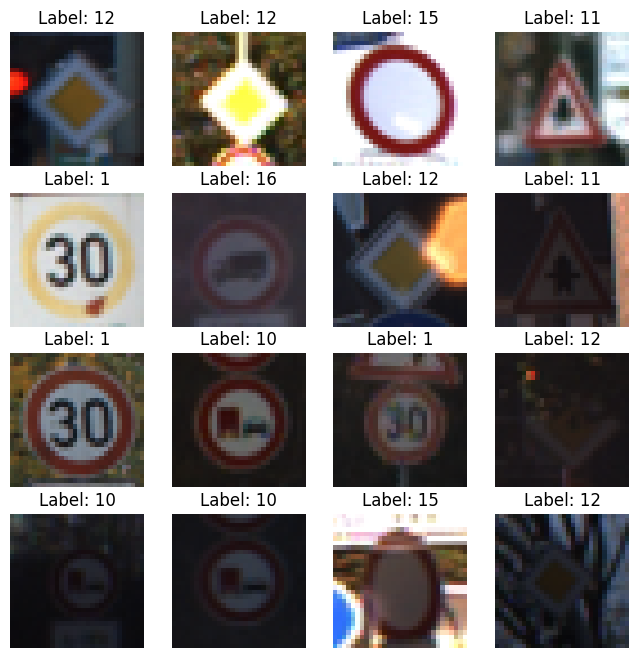

In [75]:
#---------------------------------------------------#
# Visualizing images within our training dataset
#---------------------------------------------------#
num_images = 16

plt.figure(figsize=(8, 8))
for i in range(num_images):
    plt.subplot(4, 4, i+1)  # 3x3 grid
    plt.imshow(X_train[i])   # X_train images are already numpy arrays
    plt.title(f"Label: {np.argmax(y_train[i])}")  # Show label (one-hot back to index)
    plt.axis('off')          # Hide axes
plt.show()


In [76]:
#-----------------------------------------#
#Data Augmentation
#-----------------------------------------#


datagen = ImageDataGenerator(
    rotation_range=15,         # rotate images ±15 degrees
    zoom_range=0.2,            # random zoom
    width_shift_range=0.2,     # horizontal shift
    height_shift_range=0.2,    # vertical shift
    shear_range=0.15,          # shear transformation
    brightness_range=[0.7, 1.3],  # random brightness
    horizontal_flip=False,     # traffic signs usually not flipped
    fill_mode='nearest'        # fill pixels after transformations
)
datagen.fit(X_train)

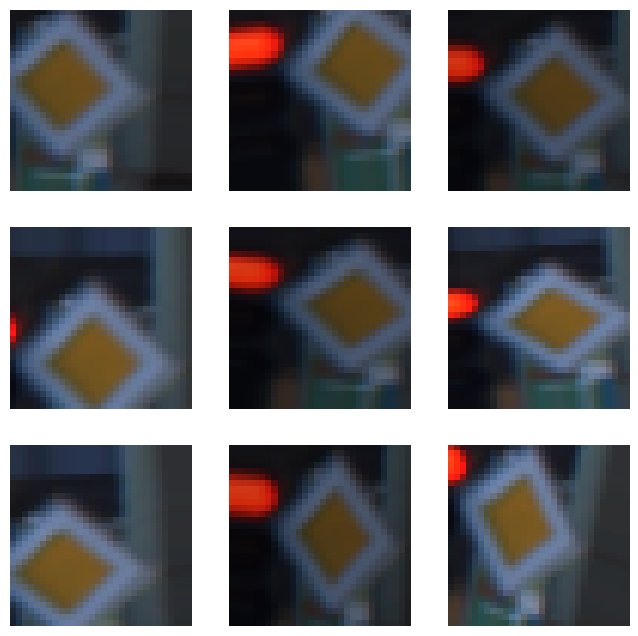

In [77]:
#---------------------------------------#
# VISUALIZING AUGMENTATED IMAGES
#---------------------------------------#
sample_img = X_train[0].reshape((1, *X_train[0].shape))

plt.figure(figsize=(8,8))
i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(3, 3, i+1)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    i += 1
    if i >= 9:
        break
plt.show()


In [ ]:
#-----------------------------------------------#
#BUILDING OUR CNN MODEL
#-----------------------------------------------#

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Classification head
model.add(GlobalAveragePooling2D())  # reduces parameters, helps generalization
model.add(Dense(256, activation='relu', kernel_initializer='he_normal'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 332,875 (1.27 MB)

 Trainable params: 331,979 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

In [80]:
#---------------------------------------------#
# COMPILATION OF THE MODEL 
#---------------------------------------------#


# Use a learning rate schedule for better convergence
optimizer = Adam(learning_rate=0.001)  # can adjust later or use a scheduler

model.compile(
    loss='categorical_crossentropy',   # multi-class classification
    optimizer=optimizer,
    metrics=['accuracy']
)

In [ ]:
#--------------------------------#
# MODEL TRAINING
#---------------------------------#

eps = 20
cnn_model = model.fit(X_train, y_train, batch_size=32, epochs=eps, validation_data=(X_test, y_test))

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.7165 - loss: 0.9945 - val_accuracy: 0.8713 - val_loss: 0.4233
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.9463 - loss: 0.1680 - val_accuracy: 0.9583 - val_loss: 0.1236
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9797 - loss: 0.0614 - val_accuracy: 0.9948 - val_loss: 0.0115
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.9984 - val_loss: 0.0042
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.9880 - loss: 0.0369 - val_accuracy: 0.9974 - val_loss: 0.0059
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9979 - val_loss: 0.0067
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9984 - val_loss: 0.0043
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9986 - loss: 0.0057 - 

In [126]:
#------------------------#
#EVALUATE THE MODEL
#------------------------#


from sklearn.metrics import accuracy_score
'''y_test = pd.read_csv('/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   image = Image.open(img)
   image = image.resize((30,30))
   data.append(np.array(image))
X_test=np.array(data)
pred = model.predict_classes(X_test)
print(accuracy_score(labels, pred))'''

from PIL import Image
import os

# Load CSV
base_folder = '/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset'
y_test = pd.read_csv(os.path.join(base_folder, 'Test.csv'))

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

# Load and preprocess images
data = []
for img in imgs:
    img_path = os.path.join(base_folder, img)
    image = Image.open(img_path)
    image = image.resize((30,30))
    data.append(np.array(image))

X_test = np.array(data, dtype=np.float32) / 255.0

# Predict
pred_probs = model.predict(X_test)
pred = np.argmax(pred_probs, axis=1)


# Base folder containing CSV and images


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Test/09593.png'

In [106]:
#SAVE MODEL
model.save("traffic_classifier.h5")

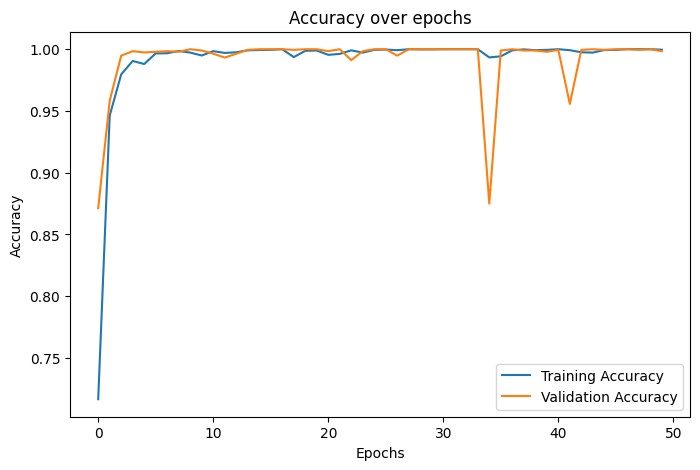

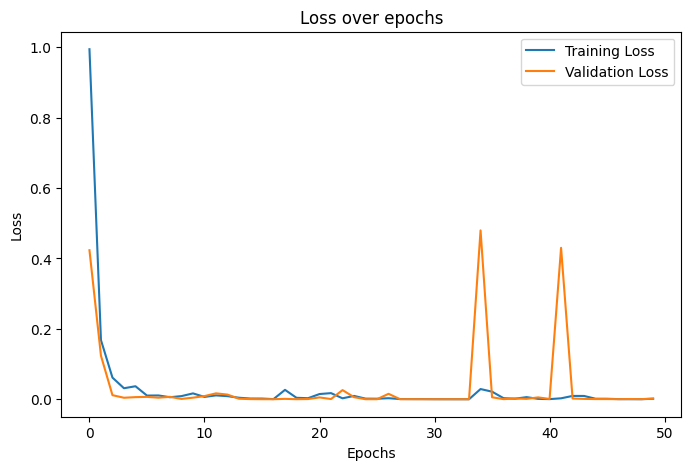

In [104]:
#--------------------------------------------#

#PLOTTING TRAINING AND VALIDATION ACCURACY
#--------------------------------------------#

plt.figure(figsize=(8,5))
plt.plot(cnn_model.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(cnn_model.history['loss'], label='Training Loss')
plt.plot(cnn_model.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [1]:
#testing accuracy on test dataset

from sklearn.metrics import accuracy_score
y_test = pd.read_csv('/workspaces/Elevvo_Internship_Tasks/Data/Traffic_Dataset/Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   #image = Image.open(img)
   image = image.resize((30,30))
   data.append(np.array(image))
X_test=np.array(data)

# Predict probabilities
pred = model.predict(X_test)

# Convert to class labels
pred_classes = np.argmax(pred, axis=1)
acc = accuracy_score(labels[:len(pred_classes)], pred_classes)
print("Test Accuracy:", acc)

NameError: name 'pd' is not defined

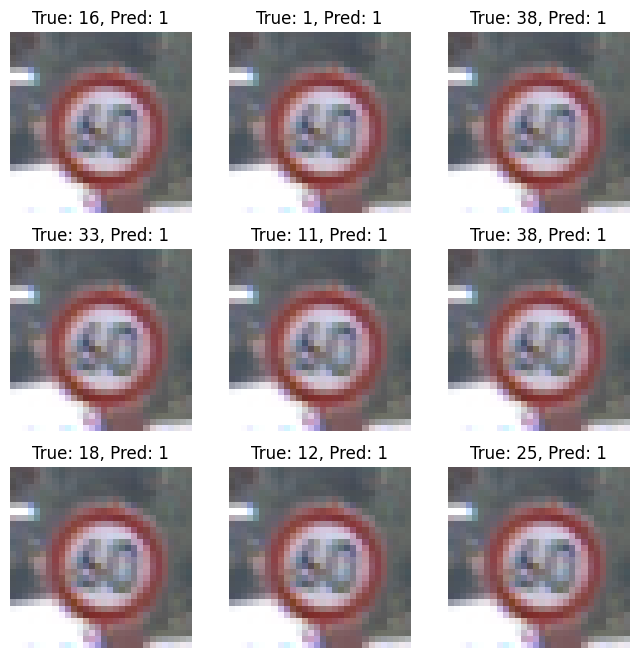

In [114]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"True: {labels[i]}, Pred: {pred_classes[i]}")
    plt.axis('off')
plt.show()